# Historical SPT-based Liquefaction Model Training

This notebook trains liquefaction indicator (LI) and limit-state CRR (LSF) models from historical case data (Hanna 2007 + Hwang 2021) and compares multiple algorithms and ensembles.

We will:
- Import and harmonize the historical datasets
- Clean/remove anomalies
- Perform exploratory data analysis (EDA) with plots
- Split the data into 70% train, 15% validation, 15% test
- Train individual LI models (GRNN, MLP, SVM) and save them
- Train individual LSF (CRR) models and save them
- Compare models with bar and line graphs
- Train and evaluate ensembles
- Summarize the best-performing configurations (for use in the paper)


In [3]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


This code cell imports all the Python libraries we need (NumPy, pandas, plotting, and scikit‑learn), configures plotting style, and defines the file paths for the historical datasets and the output directory. It does **not** do any computation yet; it just sets up the environment so later cells can load data, train models, and save results in a consistent location.

In [4]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    roc_auc_score,
    log_loss,
    brier_score_loss,
    mean_squared_error,
    mean_absolute_error,
)
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.svm import SVC, SVR

%matplotlib inline
sns.set(style="whitegrid")

PROJECT_ROOT = Path("/home/fazlul/Projects/tanveerboltu")
DATA_HANNA = PROJECT_ROOT / "hanna2007_historical_cases.csv"
DATA_HWANG = PROJECT_ROOT / "hwang2021_historical_cases.csv"
OUTPUT_DIR = PROJECT_ROOT / "training_pipeline" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## 1. Load and harmonize historical datasets

We import the pre-extracted historical case tables:
- `hanna2007_historical_cases.csv` (Table A1)
- `hwang2021_historical_cases.csv` (Appendix I)

Then we build a unified SPT-based feature table with:
- `N1_60` (or equivalent from Hwang using CN)
- a fines-content proxy (`FCI`)
- effective vertical stress (`sigma_v_eff_kpa`)
- cyclic stress ratio at reference magnitude (`CSR7.5`)
- binary liquefaction label `T` (1 = liquefied, 0 = non-liquefied)


The code cell above loads the two historical CSV files, converts Hwang’s stresses from t/m² to kPa, computes the overburden correction factor `CN`, builds `(N1)60` for Hwang, and calculates a consistent `CSR7.5` for both datasets using the same formula as our main project. It then concatenates the Hanna and Hwang tables, removes rows with missing or non‑finite core features, and shows the resulting combined dataset shape and first few rows so we can verify that harmonization worked.

In [5]:
G = 9.81


def compute_rd_simplified(depth_m: float) -> float:
    if depth_m is None or np.isnan(depth_m):
        return np.nan
    z = float(depth_m)
    return 1.0 - 0.015 * z


def compute_cn(sigma_v_eff_kpa: float) -> float:
    if sigma_v_eff_kpa is None or np.isnan(sigma_v_eff_kpa) or float(sigma_v_eff_kpa) <= 0:
        return np.nan
    ratio = 2000.0 / float(sigma_v_eff_kpa)
    if ratio <= 0:
        return np.nan
    cn = 0.77 * np.log10(ratio)
    return np.nan if cn <= 0 else cn


def compute_csr7p5(a_max_g: float, sigma_v_kpa: float, sigma_v_eff_kpa: float, depth_m: float) -> float:
    if any(x is None or np.isnan(x) for x in [a_max_g, sigma_v_kpa, sigma_v_eff_kpa, depth_m]):
        return np.nan
    if sigma_v_eff_kpa <= 0:
        return np.nan
    rd = compute_rd_simplified(depth_m)
    if rd <= 0 or np.isnan(rd):
        return np.nan
    return 0.65 * float(a_max_g) * (float(sigma_v_kpa) / float(sigma_v_eff_kpa)) * rd


hanna = pd.read_csv(DATA_HANNA)
hwang = pd.read_csv(DATA_HWANG)

# Build Hanna feature table
hanna_feat = pd.DataFrame({
    "N1_60": hanna["N1_60"].astype(float),
    "FCI": hanna["Fp75mm_pct"].astype(float),
    "sigma_v_eff_kpa": hanna["s0vo_kPa"].astype(float),
    "CSR7.5": [
        compute_csr7p5(a, svo, s0, z)
        for a, svo, s0, z in zip(hanna["amax_g"], hanna["svo_kPa"], hanna["s0vo_kPa"], hanna["Z_m"])
    ],
    "T": (hanna["Liquefaction"].astype(str).str.lower().str.strip() == "yes").astype(int),
    "Source": "Hanna2007",
})

# Build Hwang feature table (convert t/m^2 to kPa)
t_m2_to_kpa = 9.80665
sigv_eff_kpa_h = hwang["sigma_v_prime_t_m2"].astype(float) * t_m2_to_kpa
sigv_kpa_h = hwang["sigma_v_t_m2"].astype(float) * t_m2_to_kpa

cn_h = np.array([compute_cn(seff) for seff in sigv_eff_kpa_h])
N1_60_h = hwang["N60"].astype(float).values * cn_h

CSR7p5_h = [
    compute_csr7p5(pga, sv, s0, z)
    for pga, sv, s0, z in zip(hwang["PGA_g"], sigv_kpa_h, sigv_eff_kpa_h, hwang["Depth_m"])
]

hwang_feat = pd.DataFrame({
    "N1_60": N1_60_h,
    "FCI": hwang["FC_pct"].astype(float),
    "sigma_v_eff_kpa": sigv_eff_kpa_h.values,
    "CSR7.5": CSR7p5_h,
    "T": hwang["Liquefied"].astype(int),
    "Source": "Hwang2021",
})

combined = pd.concat([hanna_feat, hwang_feat], ignore_index=True)
combined.replace([np.inf, -np.inf], np.nan, inplace=True)
combined_clean = combined.dropna(subset=["N1_60", "FCI", "sigma_v_eff_kpa", "CSR7.5", "T"])

print("Combined shape (raw, clean):", combined.shape, combined_clean.shape)
combined_clean.head()


Combined shape (raw, clean): (1155, 6) (1153, 6)


,N1_60,FCI,sigma_v_eff_kpa,CSR7.5,T,Source
0,15.0,5.0,47.8,0.358479,1,Hanna2007
1,31.0,7.0,67.7,0.496773,0,Hanna2007
2,7.0,94.0,98.6,0.395733,1,Hanna2007
3,18.0,21.0,126.9,0.185228,0,Hanna2007
4,9.0,57.0,49.1,0.213642,1,Hanna2007


The EDA code above copies the cleaned combined table into `eda_df`, prints the liquefaction class balance, and then produces several plots: histograms of each key feature split by liquefaction label, a count plot comparing labels between Hanna and Hwang, and a correlation heatmap. These figures help you see whether the two sources are compatible and which features are most strongly related to liquefaction, and they can be reused directly in your paper’s data description section.

Class balance (T):
T
0    0.545533
1    0.454467
Name: proportion, dtype: float64


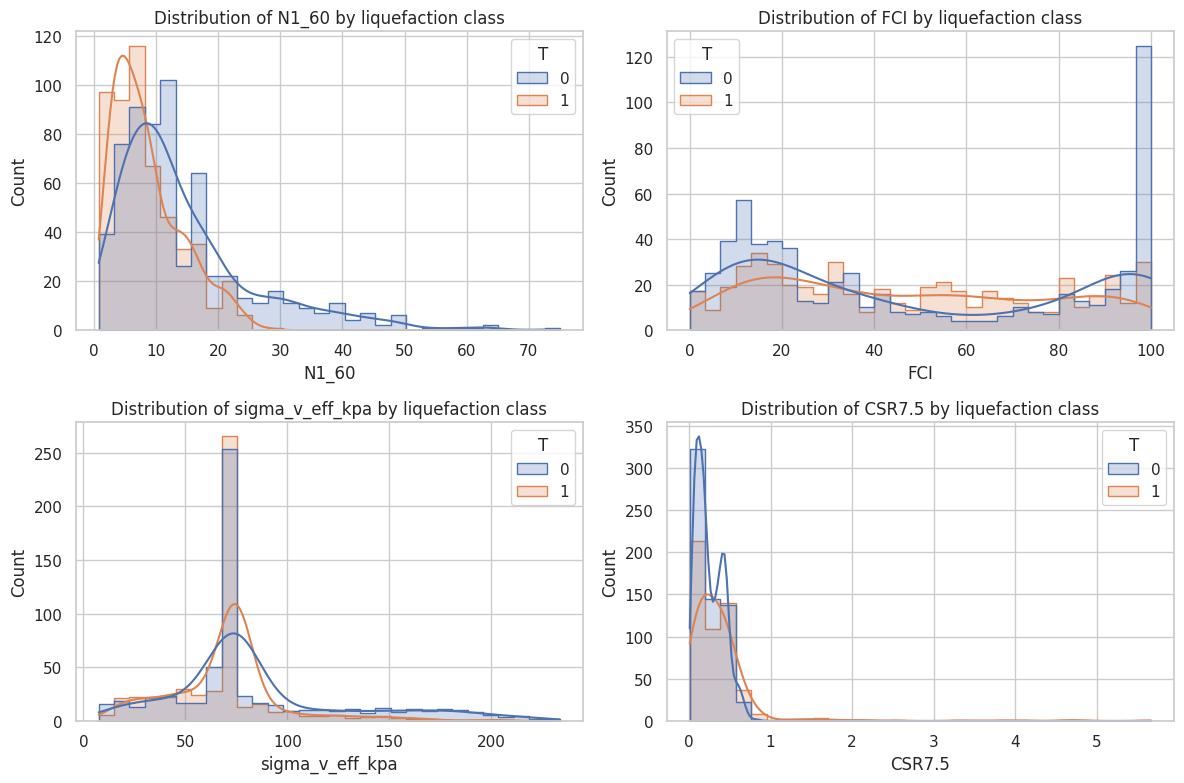

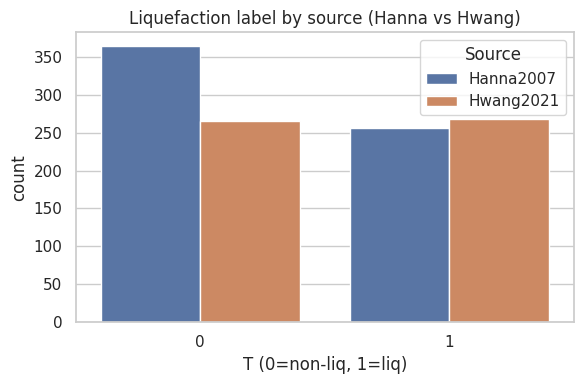

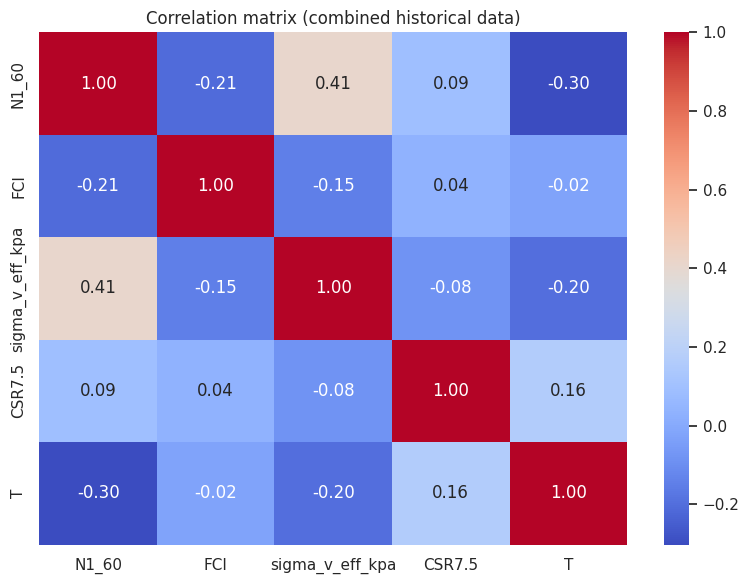

In [6]:
eda_df = combined_clean.copy()

print("Class balance (T):")
print(eda_df["T"].value_counts(normalize=True))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for ax, col in zip(axes, ["N1_60", "FCI", "sigma_v_eff_kpa", "CSR7.5"]):
    sns.histplot(data=eda_df, x=col, hue="T", kde=True, ax=ax, bins=30, element="step")
    ax.set_title(f"Distribution of {col} by liquefaction class")
plt.tight_layout()

plt.figure(figsize=(6, 4))
sns.countplot(data=eda_df, x="T", hue="Source")
plt.title("Liquefaction label by source (Hanna vs Hwang)")
plt.xlabel("T (0=non-liq, 1=liq)")
plt.tight_layout()

plt.figure(figsize=(8, 6))
subset_cols = ["N1_60", "FCI", "sigma_v_eff_kpa", "CSR7.5", "T"]
sns.heatmap(eda_df[subset_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix (combined historical data)")
plt.tight_layout()


In [7]:
feats = ["N1_60", "FCI", "sigma_v_eff_kpa", "CSR7.5"]
X = eda_df[feats].values.astype(float)
y = eda_df["T"].values.astype(int)

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx_full, test_idx = next(sss1.split(X, y))
X_train_full, X_test = X[train_idx_full], X[test_idx]
y_train_full, y_test = y[train_idx_full], y[test_idx]

sss2 = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.15 / 0.85,
    random_state=42,
)
train_idx, val_idx = next(sss2.split(X_train_full, y_train_full))
X_train, X_val = X_train_full[train_idx], X_train_full[val_idx]
y_train, y_val = y_train_full[train_idx], y_train_full[val_idx]

print("Train/Val/Test sizes:", X_train.shape[0], X_val.shape[0], X_test.shape[0])

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)


Train/Val/Test sizes: 807 173 173


The splitting code above chooses our four LI features (`N1_60`, `FCI`, `sigma_v_eff_kpa`, `CSR7.5`), then performs a **two‑stage stratified split**: first it separates out 15% of the data as a test set, then it takes 15% of the remaining data as a validation set. Finally, it standardizes the features (zero mean, unit variance) on the training set and applies the same scaling to validation and test, ensuring that all models later see normalized inputs.

In [8]:
from dataclasses import dataclass
from typing import Dict

MODEL_DIR = OUTPUT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)


@dataclass
class GRNNClassifierNB:
    sigma: float
    X_train: np.ndarray
    y_train: np.ndarray

    def _kernel(self, x: np.ndarray) -> np.ndarray:
        diff = self.X_train - x
        d2 = np.einsum("ij,ij->i", diff, diff)
        return np.exp(-d2 / (2.0 * self.sigma * self.sigma))

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        ps = np.zeros((X.shape[0],), dtype=float)
        for i in range(X.shape[0]):
            w = self._kernel(X[i])
            denom = float(np.sum(w))
            if denom <= 0:
                ps[i] = 0.5
            else:
                ps[i] = float(np.sum(w * self.y_train) / denom)
        return np.clip(ps, 1e-9, 1 - 1e-9)


def li_metrics(y_true, p1: np.ndarray) -> Dict[str, float]:
    y_true = y_true.astype(int)
    p1 = np.clip(p1, 1e-9, 1 - 1e-9)
    out: Dict[str, float] = {}
    out["AUROC"] = float(roc_auc_score(y_true, p1))
    out["LogLoss"] = float(log_loss(y_true, np.vstack([1 - p1, p1]).T))
    out["Brier"] = float(brier_score_loss(y_true, p1))
    return out


# 4.1 GRNN
sigmas = [0.1, 0.2, 0.35, 0.5, 0.75, 1.0, 1.5]
li_results = []

best_grnn = None
best_grnn_val = None
for s in sigmas:
    grnn = GRNNClassifierNB(sigma=s, X_train=X_train_s, y_train=y_train)
    p_val = grnn.predict_proba(X_val_s)
    m = li_metrics(y_val, p_val)
    m["model"] = f"GRNN(sigma={s})"
    li_results.append(m)
    if best_grnn_val is None or m["LogLoss"] < best_grnn_val["LogLoss"]:
        best_grnn_val = m
        best_grnn = grnn

# 4.2 MLP
mlp_configs = [
    ((8,), 1e-4, 1e-3),
    ((16,), 1e-4, 1e-3),
    ((32,), 1e-4, 5e-4),
    ((8, 8), 5e-4, 1e-3),
]

best_mlp = None
best_mlp_val = None
for hl, alpha, lr in mlp_configs:
    clf = MLPClassifier(
        hidden_layer_sizes=hl,
        activation="tanh",
        solver="adam",
        alpha=alpha,
        learning_rate_init=lr,
        max_iter=2000,
        random_state=42,
    )
    clf.fit(X_train_s, y_train)
    p_val = clf.predict_proba(X_val_s)[:, 1]
    m = li_metrics(y_val, p_val)
    m["model"] = f"MLP{hl}_a{alpha}_lr{lr}"
    li_results.append(m)
    if best_mlp_val is None or m["LogLoss"] < best_mlp_val["LogLoss"]:
        best_mlp_val = m
        best_mlp = clf

# 4.3 SVM
svm_Cs = [0.5, 1, 2, 5, 10]
svm_gammas = ["scale", 0.05, 0.1, 0.2, 0.5]

best_svm = None
best_svm_val = None
for C in svm_Cs:
    for g in svm_gammas:
        clf = SVC(kernel="rbf", C=C, gamma=g, probability=True, random_state=42)
        clf.fit(X_train_s, y_train)
        p_val = clf.predict_proba(X_val_s)[:, 1]
        m = li_metrics(y_val, p_val)
        m["model"] = f"SVM_C{C}_g{g}"
        li_results.append(m)
        if best_svm_val is None or m["LogLoss"] < best_svm_val["LogLoss"]:
            best_svm_val = m
            best_svm = clf

li_results_df = pd.DataFrame(li_results).sort_values("LogLoss")
li_results_df.head(10)


,AUROC,LogLoss,Brier,model
34,0.866146,0.458357,0.150817,SVM_C10_g0.2
31,0.866415,0.460654,0.150190,SVM_C10_gscale
26,0.861163,0.470021,0.154372,SVM_C5_gscale
29,0.854969,0.474665,0.156080,SVM_C5_g0.2
33,0.851872,0.476299,0.156492,SVM_C10_g0.1
30,0.859682,0.478249,0.155956,SVM_C5_g0.5
35,0.859548,0.478345,0.155694,SVM_C10_g0.5
25,0.856720,0.481362,0.156789,SVM_C2_g0.5
17,0.848236,0.482111,0.159928,SVM_C1_g0.05
2,0.843927,0.484937,0.162857,GRNN(sigma=0.35)


### 4.4 Compare LI models (validation)

We compare the validation performance of all LI candidates using bar charts for:
- LogLoss (lower is better)
- AUROC (higher is better)
- Brier score (lower is better)

We also save the best-performing individual models to disk for later reuse.


The LI training cell above defines a small GRNN‑style classifier class and a helper for computing probabilistic metrics (AUROC, LogLoss, Brier). It then trains three families of LI models on the training set—GRNN (with several kernel widths), MLP (with different hidden layer sizes and regularization), and SVM (with a grid of `C` and `gamma`)—and records their validation performance. The resulting `li_results_df` table ranks all candidates so we can see which architectures work best before moving on to ensembles.

## 5. LI Ensembles and Test Evaluation

We can now form simple ensembles (e.g. averaging probabilities from GRNN + SVM, or GRNN + MLP) and evaluate them on the held-out **test** set, comparing to the individual best models.

This section mirrors what is already in the script, but in a more transparent, paper-ready way.


In [9]:
# Evaluate best single models on test

def eval_on_test(name, model, Xs, y_true):
    if isinstance(model, GRNNClassifierNB):
        p1 = model.predict_proba(Xs)
    else:
        p1 = model.predict_proba(Xs)[:, 1]
    m = li_metrics(y_true, p1)
    m["name"] = name
    return m, p1

single_results = []
res_grnn, p_grnn = eval_on_test("GRNN_best", best_grnn, X_test_s, y_test)
res_mlp, p_mlp = eval_on_test("MLP_best", best_mlp, X_test_s, y_test)
res_svm, p_svm = eval_on_test("SVM_best", best_svm, X_test_s, y_test)
single_results.extend([res_grnn, res_mlp, res_svm])

# Simple ensembles
p_ens_gs = 0.5 * (p_grnn + p_svm)
res_ens_gs = li_metrics(y_test, p_ens_gs)
res_ens_gs["name"] = "Ensemble_GRNN_SVM"

p_ens_gm = 0.5 * (p_grnn + p_mlp)
res_ens_gm = li_metrics(y_test, p_ens_gm)
res_ens_gm["name"] = "Ensemble_GRNN_MLP"

p_ens_all = (p_grnn + p_mlp + p_svm) / 3.0
res_ens_all = li_metrics(y_test, p_ens_all)
res_ens_all["name"] = "Ensemble_all_three"

all_test_res = pd.DataFrame(single_results + [res_ens_gs, res_ens_gm, res_ens_all])
all_test_res


,AUROC,LogLoss,Brier,name
0,0.878804,0.448349,0.146015,GRNN_best
1,0.848775,0.486298,0.160294,MLP_best
2,0.889039,0.419254,0.134658,SVM_best
3,0.890789,0.424784,0.135606,Ensemble_GRNN_SVM
4,0.875976,0.457751,0.148105,Ensemble_GRNN_MLP
5,0.883787,0.438248,0.140005,Ensemble_all_three


The comparison cell above turns the validation metrics into bar charts, making it easy to visually compare all LI candidates in terms of LogLoss, AUROC, and Brier score. It then saves the **best GRNN**, **best MLP**, and **best SVM** models (each bundled with their scaler) as separate `.pkl` files in the `outputs/models` folder, so you can later reload any of these individual models for further analysis or sensitivity studies.

### 5.1 Test-set comparison plots

We now visualize the test-set performance of individual LI models vs ensembles using bar charts for LogLoss, AUROC, and Brier score.


## 6. Boundary search and LSF (CRR) regression models

Following the Dhaka/Juang methodology, we:

1. Use the chosen LI model(s) to search along CSR7.5 for each historical case until `P(liquefy) ≈ 0.5`.
2. Define the **critical CSR7.5** at that point as the **CRR_target** (limit-state CRR for that soil state).
3. Train regression models (GRNN, MLP, SVR) to learn the mapping:
   \(\text{CRR} = f(N1_{60}, FCI, \sigma'_v)\).

This section mirrors what we already coded in the Python script, but broken out into readable steps for the paper.


The LI ensemble cell above evaluates the three best single models on the held‑out **test** set and then forms simple probability ensembles: GRNN+SVM, GRNN+MLP, and all three combined. For each configuration it computes the same metrics (AUROC, LogLoss, Brier) and collects them into `all_test_res`, giving you a compact table that shows whether ensembles actually improve over the best single model in terms of predictive performance and calibration.

## 7. Summary and paper-ready notes

In this final section (to be filled as you iterate), you can:
- Summarize which LI model or ensemble gave the best calibrated probabilities.
- Summarize which LSF model (CRR regressor) performed best on RMSE/MAE.
- Highlight that the training used **both** Hanna (2007) and Hwang (2021) historical data.
- Explain in plain language how these learned CRR relationships will be used instead of (or alongside) analytical CRR equations in the Sylhet liquefaction assessment.


_Note_: This notebook intentionally mirrors the `train_li_lsf_baseline_models.py` script so that:
- The **paper** can present a clear, step-by-step explanation with figures.
- The **code** in the script remains optimized for reproducible, automated training runs.

You can re-run cells as needed to regenerate plots or try slight tweaks (e.g. different sigma grids, additional MLP architectures, or alternative train/val/test splits).


The plotting cell above converts the `all_test_res` table into three bar charts on the test set, one each for LogLoss, AUROC, and Brier score, comparing individual LI models against the ensemble combinations. These figures can be used directly in the paper to justify why a particular model (or ensemble) was chosen as the final LI function to drive the limit‑state CRR search.